In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow.keras.backend as K
K.set_image_data_format('channels_last')

import tqdm
import random
import numpy as np
import neurite as ne
import voxelmorph as vxm
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

2025-09-30 10:24:29.321695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759220669.345244  892627 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759220669.352331  892627 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-30 10:24:29.382283: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import tensorflow as tf
import neurite as ne
import voxelmorph as vxm
import numpy as np

# Model input shape
in_shape = (256, 256)
num_label = 16

# Define image synthesis models (used only to define model structure)
prop = dict(
    in_shape=in_shape,
    out_shape=in_shape,
    labels_in=range(num_label),
    warp_max=4,
    warp_blur_min=(8, 8),
    warp_blur_max=(64, 64),
)
model_gen_1 = ne.models.labels_to_image(**prop, id=1)
model_gen_2 = ne.models.labels_to_image(**prop, id=2)

# Define the registration model
model_def = vxm.networks.VxmDense(
    inshape=in_shape,
    int_resolution=2,
    svf_resolution=2,
    nb_unet_features=([256] * 4, [256] * 8),
    reg_field='warp',
)

# Get model outputs from synthesis models
ima_1, map_1 = model_gen_1.outputs
ima_2, map_2 = model_gen_2.outputs

# Apply registration
_, warp = model_def((ima_1, ima_2))
moved = vxm.layers.SpatialTransformer(fill_value=0)((map_1, warp))

# Add losses — needed for model to compile but won’t affect inference
class AddLoss(tf.keras.layers.Layer):
    def call(self, x):
        moved, map_2, warp = x
        const = tf.zeros((tf.shape(moved)[0], 1))
        self.add_loss(vxm.losses.MSE().loss(moved, map_2) + const)
        self.add_loss(vxm.losses.Grad('l2', loss_mult=0.05).loss(None, warp))
        return x

# Combine everything into a full model
inputs = (*model_gen_1.inputs, *model_gen_2.inputs)
model = tf.keras.Model(inputs, AddLoss()((moved, map_2, warp)))

# Load pretrained weights
model.load_weights('weights.h5')

# --- Now you can use model.predict(...) with label maps as input ---
# Example:
# label_maps = np.load('your_label_maps.npy')  # Load your input label maps
# input_1 = np.expand_dims(label_maps[0], axis=(0, -1))
# input_2 = np.expand_dims(label_maps[1], axis=(0, -1))
# result = model.predict([input_1, input_2])


/home/students/studweilc1/.conda/envs/synth2/lib/python3.10/site-packages/neurite/tf/models.py:1082: UserWarning: model `labels_to_image` will switch from `ne.layers.Subsample` to `vxm.layers.DownUpSample` soon. Enable the new behavior by setting `slice_new=True`.
  warnings.warn('model `labels_to_image` will switch from `ne.layers.Subsample` to '
/home/students/studweilc1/.conda/envs/synth2/lib/python3.10/site-packages/neurite/tf/models.py:1088: UserWarning: argument `warp_zero_mean` to `labels_to_image` is deprecated and will be removed in the future, as the SVF components will always have zero mean. Enable the new behavior by setting `warp_zero_mean=True`.
  warnings.warn('argument `warp_zero_mean` to `labels_to_image` is deprecated and will be '
2025-09-30 10:24:36.428558: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-09-30 10:24:36.4

In [3]:
# Resize and normalize test images.
def conform(x, in_shape=in_shape):
    x = np.float32(x)
    x = np.squeeze(x)
    x = ne.utils.minmax_norm(x)
    x = ne.utils.zoom(x, zoom_factor=[o / i for o, i in zip(in_shape, x.shape)])
    return x[None, ..., None]

def register(moving, fixed):
    # Conform and register.
    moving = conform(moving)
    fixed = conform(fixed)
    moved, warp = model_def.predict((moving, fixed), verbose=0)

    # Visualize.
    slices = (moving, fixed, moved, warp[..., 0])
    titles = ('Moving', 'Fixed', 'Moved', 'Warp (x-axis)')
    ne.plot.slices(slices, titles, do_colorbars=True)

def transform_img(img):
    # Transform the image to the desired shape
    img = np.squeeze(img, axis=0)  # Remove batch dimension
    img = np.expand_dims(img, axis=-1)  # Add channel dimension
    return img

def register_img(sample):
    img_template = sample["image_template"]
    img_moving = sample["image_moving"]
    img_template = transform_img(img_template)
    img_moving = transform_img(img_moving)
    register(moving=img_moving, fixed=img_template)

def plot_slices_with_mask(slices, slices_masks, titles):
    fig, axes = plt.subplots(1, len(slices), figsize=(15, 5))
    for ax, img, img_mask, title in zip(axes, slices, slices_masks, titles):
        ax.imshow(img, cmap='gray')
        if img_mask is not None:
            # create empty mask if img_mask is None
            ax.imshow(img_mask, cmap='gray', alpha=0.35)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def register_img_with_mask(sample):
    img_template = sample["image_template"]
    img_moving = sample["image_moving"]
    img_mask_template = sample["mask_template"]
    img_mask_moving = sample["mask_moving"]

    img_template = transform_img(img_template)
    img_moving = transform_img(img_moving)
    img_mask_template = transform_img(img_mask_template)
    img_mask_moving = transform_img(img_mask_moving)

    # Register the images
    moving, fixed = img_moving, img_template
    moved, warp = model_def.predict((moving[None, ...], fixed[None, ...]), verbose=0)

    # Visualize with masks
    slices = (fixed, moving, moved[0, ..., 0], warp[0, ..., 0])
    slices_masks = (img_mask_template, img_mask_moving, None, None)
    titles = ('Fixed', 'Moving', 'Moved', 'Warp (x-axis)')
    
    plot_slices_with_mask(slices, slices_masks, titles)



In [36]:
# caculate dice similarity coefficient
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_coefficient_numpy(y_true, y_pred, smooth=1e-6):
    y_true_f = np.reshape(y_true, [-1])
    y_pred_f = np.reshape(y_pred, [-1])
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)


def calculate_dice_scores(sample, normalize = False):
    img_template = sample["image_template"]
    img_moving = sample["image_moving"]
    mask_template = sample["mask_template"]
    mask_moving = sample["mask_moving"]
    img_template = transform_img(img_template)
    img_moving = transform_img(img_moving)
    mask_template = transform_img(mask_template)
    mask_moving = transform_img(mask_moving)

    moving = conform(img_moving)
    fixed = conform(img_template)

    if normalize:
        # 0-1 normalize the images
        moving = (moving - np.min(moving)) / (np.max(moving) - np.min(moving))
        fixed = (fixed - np.min(fixed)) / (np.max(fixed) - np.min(fixed))
    moved, warp = model_def.predict((moving, fixed), verbose=0)

    moved_mask = vxm.layers.SpatialTransformer(fill_value=0)((np.expand_dims(mask_moving, axis=0), warp))
    dice_score = dice_coefficient(mask_template, mask_moving)
    dice_score_warped = dice_coefficient(mask_template, moved_mask[0,:,:,0])
    return float(dice_score), float(dice_score_warped)


def calculate_dice_scores_complete(fixed_imgs, moving_imgs, fixed_masks, moving_masks, index=0, normalize=False):
    sample = {
        "image_template": np.expand_dims(fixed_imgs[index], axis=0),
        "image_moving": np.expand_dims(moving_imgs[index], axis=0),
        "mask_template": np.expand_dims(fixed_masks[index], axis=0),
        "mask_moving": np.expand_dims(moving_masks[index], axis=0),
    }
    return calculate_dice_scores(sample, normalize=normalize)

def calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks, normalize=False):
    dice_scores = []
    dice_scores_warped = []
    for i in tqdm.tqdm(range(len(fixed_imgs))):
        dice_score, dice_score_warped = calculate_dice_scores_complete(fixed_imgs, moving_imgs, fixed_masks, moving_masks, index=i, normalize=normalize)
        dice_scores.append(dice_score)
        dice_scores_warped.append(dice_score_warped)
    return dice_scores, dice_scores_warped

#### Evaluation

In [6]:
target_path = "../data/my_data2/test/DIXON.npy"
target_masks_path = "../data/my_data2/test/DIXON_masks.npy"

moving_path = "../data/my_data2/test/T1_mapping_fl2d.npy"
moving_masks_path = "../data/my_data2/test/T1_mapping_fl2d_masks.npy"

# Load the numpy arrays
moving_imgs = np.load(moving_path)
fixed_imgs = np.load(target_path)
moving_masks = np.load(moving_masks_path)
fixed_masks = np.load(target_masks_path)

In [7]:
sample = {
    "image_template": np.expand_dims(fixed_imgs[0], axis=0),
    "image_moving": np.expand_dims(moving_imgs[0], axis=0),
    "mask_template": np.expand_dims(fixed_masks[0], axis=0),
    "mask_moving": np.expand_dims(moving_masks[0], axis=0),
}

calculate_dice_scores(sample)

(0.9275956153869629, 0.9066663980484009)

#### T1

In [8]:
target_path = "../data/my_data2/test/DIXON.npy"
target_masks_path = "../data/my_data2/test/DIXON_masks.npy"

moving_path = "../data/my_data2/test/T1_mapping_fl2d.npy"
moving_masks_path = "../data/my_data2/test/T1_mapping_fl2d_masks.npy"

moving_masks_path_filled = "../data/my_data2/test/T1_mapping_fl2d_masks_filled.npy"

# Load the numpy arrays
moving_imgs = np.load(moving_path)
fixed_imgs = np.load(target_path)
moving_masks = np.load(moving_masks_path)
fixed_masks = np.load(target_masks_path)
moving_masks_filled = np.load(moving_masks_path_filled)

In [30]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:33<00:00,  3.09it/s]


(np.float64(0.8135804241946106), np.float64(0.8682237407907241))

In [31]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks_filled)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:33<00:00,  3.08it/s]


(np.float64(0.8119609689178595), np.float64(0.8634900772270893))

#### Diffusion

In [32]:


moving_path = "../data/my_data2/test/Diffusion.npy"
moving_masks_path = "../data/my_data2/test/Diffusion_masks.npy"
moving_masks_path_filled = "../data/my_data2/test/Diffusion_masks_filled.npy"

# Load the numpy arrays
moving_imgs = np.load(moving_path)
moving_masks = np.load(moving_masks_path)
moving_masks_filled = np.load(moving_masks_path_filled)

In [33]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:32<00:00,  3.15it/s]


(np.float64(0.7561920258928748), np.float64(0.8306964708893907))

In [34]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks_filled)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:32<00:00,  3.16it/s]


(np.float64(0.7569226870934168), np.float64(0.8287376331932405))

#### BOLD

In [ ]:


moving_path = "../data/my_data2/test/BOLD.npy"
moving_masks_path = "../data/my_data2/test/BOLD_masks.npy"
moving_masks_path_filled = "../data/my_data2/test/BOLD_masks_filled.npy"

# Load the numpy arrays
moving_imgs = np.load(moving_path)
moving_masks = np.load(moving_masks_path)
moving_masks_filled = np.load(moving_masks_path_filled)

In [36]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:32<00:00,  3.18it/s]


(np.float64(0.8534186608066746), np.float64(0.8665553559275234))

In [37]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, moving_imgs, fixed_masks, moving_masks_filled)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:32<00:00,  3.15it/s]


(np.float64(0.8546888299432456), np.float64(0.8671591679255167))

## Synthetic Data

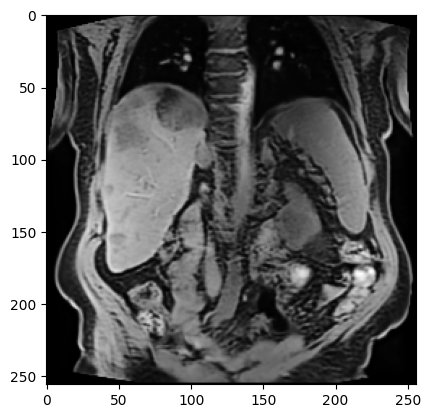

In [26]:
synthetic_img_path = "../predictions/exp_brats2/test/synthetic/sample_000.png"
synthetic_img = plt.imread(synthetic_img_path)
synthetic_img = np.flip(np.rot90(synthetic_img, -1), 1)
plt.imshow(synthetic_img, cmap='gray')

In [27]:
target_path = "../data/my_data2/test/DIXON.npy"
target_masks_path = "../data/my_data2/test/DIXON_masks.npy"

fixed_imgs = np.load(target_path)
fixed_masks = np.load(target_masks_path)

masks_Diffusion_path = "../data/my_data2/test/Diffusion_masks.npy"
masks_Diffusion = np.load(masks_Diffusion_path)
masks_BOLD_path = "../data/my_data2/test/BOLD_masks.npy"
masks_BOLD = np.load(masks_BOLD_path)
masks_T1_path = "../data/my_data2/test/T1_mapping_fl2d_masks.npy"
masks_T1 = np.load(masks_T1_path)

In [ ]:
def load_png(path):
    img = plt.imread(path)
    img = np.flip(np.rot90(img, -1), 1)
    return img

def load_all_synthetic_images(path_to_fixed, num_of_images=100):
    synthetic_imgs = []
    for i in range(num_of_images):
        img_path = os.path.join(path_to_fixed, f"synthetic/sample_{i:03d}.png")
        img = load_png(img_path)
        synthetic_imgs.append(img)
    return np.array(synthetic_imgs)

synthetic_imgs = load_all_synthetic_images(path_to_fixed="../predictions/exp_brats2/test", num_of_images=102)

In [31]:
sample = {
    "image_template": np.expand_dims(fixed_imgs[0], axis=0),
    "image_moving": np.expand_dims(synthetic_imgs[0], axis=0),
    "mask_template": np.expand_dims(fixed_masks[0], axis=0),
    "mask_moving": np.expand_dims(masks_T1[0], axis=0),
}

calculate_dice_scores(sample)

(0.9275956153869629, 0.9210548996925354)

In [32]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, synthetic_imgs, fixed_masks, masks_T1)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:35<00:00,  2.87it/s]


(np.float64(0.8135804241946106), np.float64(0.8395076031947801))

In [33]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, synthetic_imgs, fixed_masks, masks_BOLD)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:34<00:00,  2.98it/s]


(np.float64(0.8534186608066746), np.float64(0.8565318184156044))

In [39]:
dice_scores, dice_scores_warped = calculate_all_dice_scores(fixed_imgs, synthetic_imgs, fixed_masks, masks_Diffusion)
np.mean(dice_scores), np.mean(dice_scores_warped)

100%|██████████| 102/102 [00:31<00:00,  3.20it/s]


(np.float64(0.7561920258928748), np.float64(0.7699998766183853))